 HOSPITAL EMERGENCY DEPARTMENT OPTIMIZATION

Running Grid Search Optimization...
----------------------------------------------------------------------
Testing 216 configurations...
Config   Nurses   PAs      Techs    LoS       
----------------------------------------------------------------------
1        1        1        1        3073.77   
2        1        1        2        1845.91   
3        1        1        3        1844.61   
4        1        1        4        1844.60   
5        1        1        5        1844.60   
10       1        2        4        469.27    
20       1        4        2        1073.75   
30       1        5        6        63.14     
40       2        1        4        1844.60   
50       2        3        2        1073.75   
60       2        4        6        58.47     
70       2        6        4        108.37    
80       3        2        2        1073.75   
90       3        3        6        71.10     
100      3        5        4        107.41

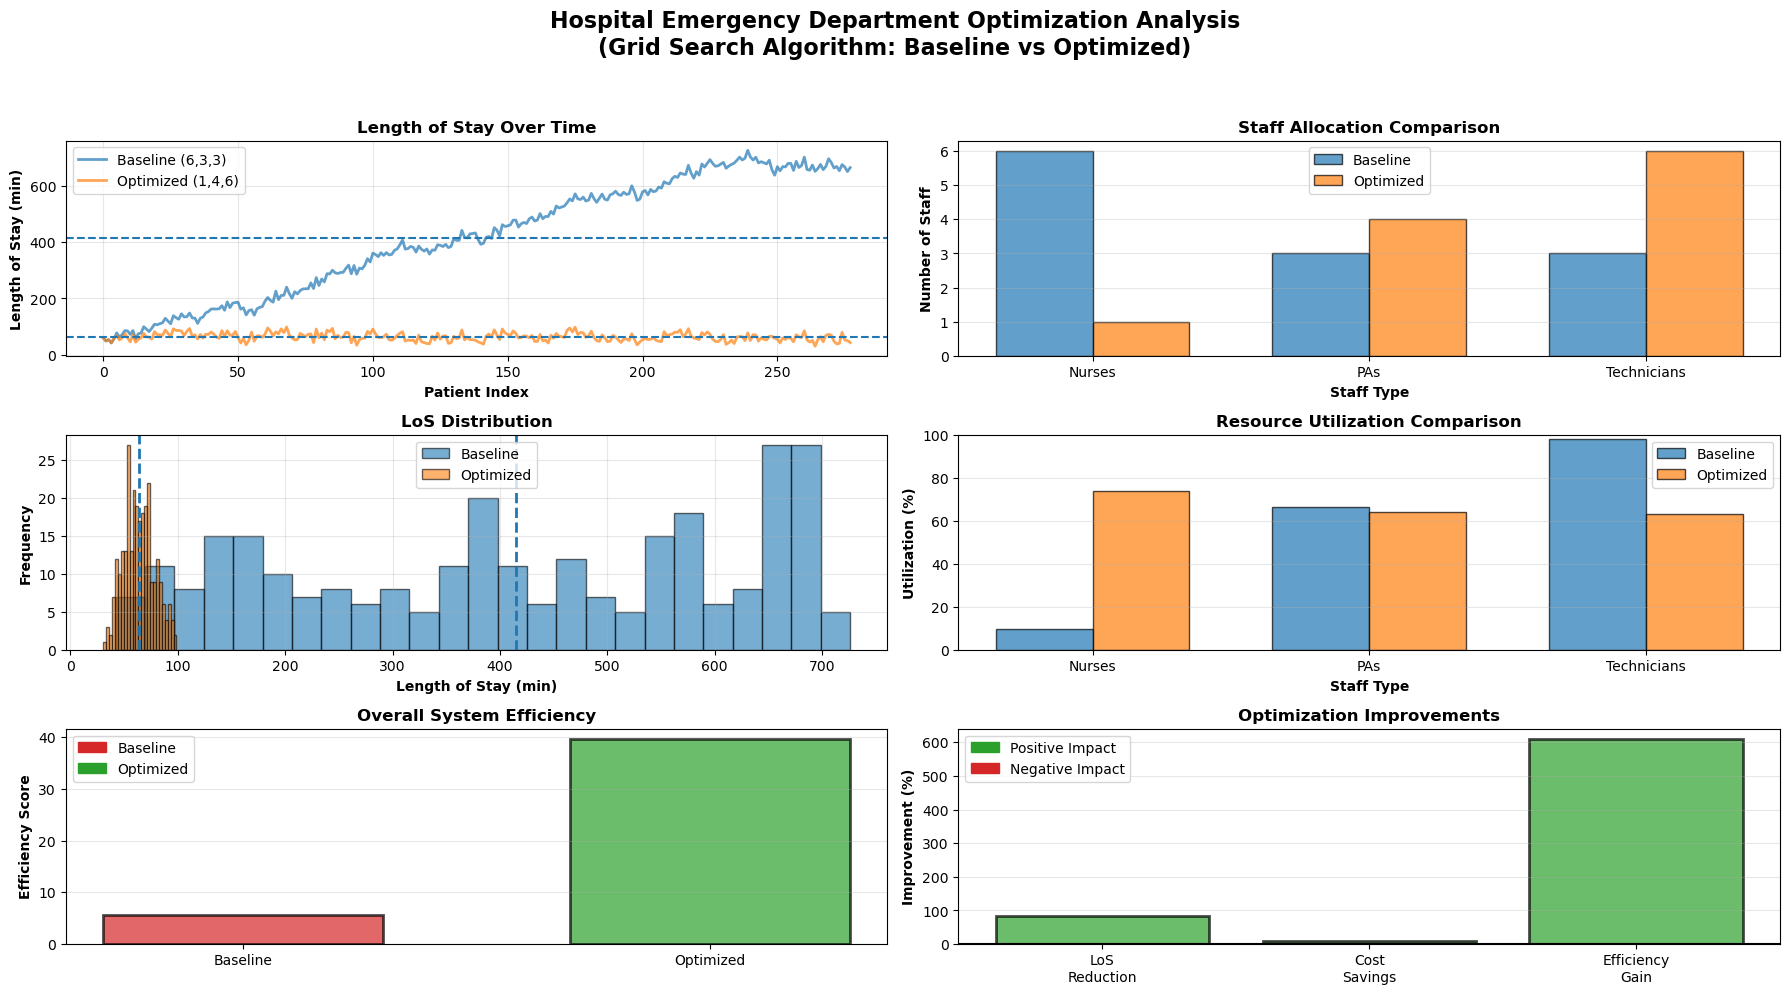

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product

print("="*70)
print(" HOSPITAL EMERGENCY DEPARTMENT OPTIMIZATION")
print("="*70)

def simulate_emergency_department(nurses, pas, technicians, sim_time=2080, arrival_rate=8, seed=42):
    """
    Time-based discrete event simulation of ED
    sim_time: simulation duration in minutes (2080 min = 34.67 hours)
    """
    np.random.seed(seed)
    
    arrival_rate_per_min = arrival_rate / 60.0
    mean_interarrival_time = 1.0 / arrival_rate_per_min

    # Generating patient arrivals using Poisson process
    arrivals = []
    t = np.random.exponential(mean_interarrival_time)
    while t < sim_time:
        arrivals.append(t)
        t += np.random.exponential(mean_interarrival_time)
    
    nurse_free = [0.0] * nurses
    pa_free = [0.0] * pas
    tech_free = [0.0] * technicians
    
    nurse_busy = [0.0] * nurses
    pa_busy = [0.0] * pas
    tech_busy = [0.0] * technicians
    
    patient_los = []
    
    for arrival in arrivals:

        # Service times
        triage_time = np.random.uniform(3, 8)
        assessment_time = np.random.uniform(10, 30)
        treatment_time = np.random.uniform(15, 45)

        # Triage (Nurse)
        nurse_idx = np.argmin(nurse_free)
        triage_start = max(arrival, nurse_free[nurse_idx])
        triage_end = triage_start + triage_time
        nurse_busy[nurse_idx] += triage_time 
        nurse_free[nurse_idx] = triage_end

        # Assessment (PA)
        pa_idx = np.argmin(pa_free)
        assess_start = max(triage_end, pa_free[pa_idx])
        assess_end = assess_start + assessment_time
        pa_busy[pa_idx] += assessment_time
        pa_free[pa_idx] = assess_end

        # Treatment (Technician)
        tech_idx = np.argmin(tech_free)
        treat_start = max(assess_end, tech_free[tech_idx])
        treat_end = treat_start + treatment_time
        tech_busy[tech_idx] += treatment_time
        tech_free[tech_idx] = treat_end
        
        los = treat_end - arrival
        patient_los.append(los)
    
    sim_end = max(max(nurse_free), max(pa_free), max(tech_free))
    
    nurse_util = sum(nurse_busy) / (nurses * sim_end)
    pa_util = sum(pa_busy) / (pas * sim_end)
    tech_util = sum(tech_busy) / (technicians * sim_end)
    
    return {
        'meanLoS': np.mean(patient_los),
        'throughput': len(patient_los),
        'nurse_util': nurse_util,
        'pa_util': pa_util,
        'tech_util': tech_util,
        'total_staff': nurses + pas + technicians,
        'patient_los_list': patient_los
    }

def grid_search_optimization():
    print("\nRunning Grid Search Optimization...")
    print("-"*70)
    
    nurse_range = range(1, 7)
    pa_range = range(1, 7)
    tech_range = range(1, 7)
    
    results = []
    total_configs = len(nurse_range) * len(pa_range) * len(tech_range)
    
    print(f"Testing {total_configs} configurations...")
    print(f"{'Config':<8} {'Nurses':<8} {'PAs':<8} {'Techs':<8} {'LoS':<10}")
    print("-"*70)
    
    config_num = 0
    for nurses, pas, techs in product(nurse_range, pa_range, tech_range):
        config_num += 1
        
        result = simulate_emergency_department(nurses, pas, techs)
        result['nurses'] = nurses
        result['pas'] = pas
        result['techs'] = techs
        result['objective'] = result['meanLoS'] - (20 * (result['nurse_util'] + 
                                                          result['pa_util'] + 
                                                          result['tech_util']))
        results.append(result)
        
        if config_num % 10 == 0 or config_num <= 5:
            print(f"{config_num:<8} {nurses:<8} {pas:<8} {techs:<8} {result['meanLoS']:<10.2f}")
    
    print("-"*70)
    print(f"Grid search complete. Tested {len(results)} configurations.\n")
    
    return pd.DataFrame(results)

results_df = grid_search_optimization()
results_df = results_df.sort_values('objective').reset_index(drop=True)

print("\nTOP 10 OPTIMAL CONFIGURATIONS:")
print("="*70)
top_10 = results_df.head(10)[['nurses', 'pas', 'techs', 'meanLoS', 
                               'nurse_util', 'pa_util', 
                               'tech_util', 'total_staff', 'objective']]
print(top_10.to_string(index=False))

best = results_df.iloc[0]
print("\n" + "="*70)
print("OPTIMAL CONFIGURATION:")
print("="*70)
print(f"   Nurses: {int(best['nurses'])}")
print(f"   PAs: {int(best['pas'])}")
print(f"   Technicians: {int(best['techs'])}")
print(f"   Total Staff: {int(best['total_staff'])}")
print(f"   Mean LoS: {best['meanLoS']:.2f} minutes")
print(f"   Nurse Utilization: {best['nurse_util']*100:.1f}%")
print(f"   PA Utilization: {best['pa_util']*100:.1f}%")
print(f"   Tech Utilization: {best['tech_util']*100:.1f}%")
print(f"   Objective Score: {best['objective']:.2f}")
print("="*70)

# Baseline comparison
baseline = simulate_emergency_department(6, 3, 3)
baseline_data = baseline.copy()

los_improvement = ((best['meanLoS'] - baseline['meanLoS']) / baseline['meanLoS'] * 100)
cost_reduction = ((baseline['total_staff'] - best['total_staff']) / baseline['total_staff'] * 100)

print("\nCOMPARISON WITH BASELINE (6,3,3):")
print("-"*70)
print(f"{'Metric':<25} {'Baseline':<15} {'Optimized':<15} {'Change':<15}")
print("-"*70)
print(f"{'Mean LoS (min)':<25} {baseline['meanLoS']:<15.2f} {best['meanLoS']:<15.2f} {los_improvement:>+.1f}%")
print(f"{'Total Staff':<25} {baseline['total_staff']:<15} {int(best['total_staff']):<15} {cost_reduction:>+.1f}%")
print(f"{'Nurse Util (%)':<25} {baseline['nurse_util']*100:<15.1f} {best['nurse_util']*100:<15.1f} {((best['nurse_util']-baseline['nurse_util'])/baseline['nurse_util']*100):>+.1f}%")
print(f"{'PA Util (%)':<25} {baseline['pa_util']*100:<15.1f} {best['pa_util']*100:<15.1f} {((best['pa_util']-baseline['pa_util'])/baseline['pa_util']*100):>+.1f}%")
print(f"{'Tech Util (%)':<25} {baseline['tech_util']*100:<15.1f} {best['tech_util']*100:<15.1f} {((best['tech_util']-baseline['tech_util'])/baseline['tech_util']*100):>+.1f}%")
print("-"*70)

# Visualizations
fig = plt.figure(figsize=(18, 12.5))

# Length of Stay Over Time
ax1 = plt.subplot(4, 2, 1)
ax1.plot(baseline_data['patient_los_list'],
         label='Baseline (6,3,3)', alpha=0.7, linewidth=2)
best_sim = simulate_emergency_department(
    int(best['nurses']), int(best['pas']), int(best['techs']), seed=42
)
ax1.plot(best_sim['patient_los_list'],
         label=f"Optimized ({int(best['nurses'])},{int(best['pas'])},{int(best['techs'])})",
         alpha=0.7, linewidth=2)
ax1.axhline(baseline['meanLoS'], linestyle='--', linewidth=1.5)
ax1.axhline(best['meanLoS'], linestyle='--', linewidth=1.5)
ax1.set_xlabel('Patient Index', fontweight='bold')
ax1.set_ylabel('Length of Stay (min)', fontweight='bold')
ax1.set_title('Length of Stay Over Time', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Staff Configuration
ax2 = plt.subplot(4, 2, 2)
categories = ['Nurses', 'PAs', 'Technicians']
baseline_staff = [6, 3, 3]
optimal_staff = [int(best['nurses']), int(best['pas']), int(best['techs'])]
x = np.arange(len(categories))
width = 0.35

ax2.bar(x - width/2, baseline_staff, width,
        label='Baseline', alpha=0.7, edgecolor='black')
ax2.bar(x + width/2, optimal_staff, width,
        label='Optimized', alpha=0.7, edgecolor='black')

ax2.set_xlabel('Staff Type', fontweight='bold')
ax2.set_ylabel('Number of Staff', fontweight='bold')
ax2.set_title('Staff Allocation Comparison', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# LoS Distribution
ax3 = plt.subplot(4, 2, 3)
ax3.hist(baseline_data['patient_los_list'], bins=25,
         alpha=0.6, label='Baseline', edgecolor='black')
ax3.hist(best_sim['patient_los_list'], bins=25,
         alpha=0.6, label='Optimized', edgecolor='black')
ax3.axvline(baseline['meanLoS'], linestyle='--', linewidth=2)
ax3.axvline(best['meanLoS'], linestyle='--', linewidth=2)
ax3.set_xlabel('Length of Stay (min)', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.set_title('LoS Distribution', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Resource Utilization
ax4 = plt.subplot(4, 2, 4)
baseline_utils = [baseline['nurse_util']*100,
                  baseline['pa_util']*100,
                  baseline['tech_util']*100]
optimal_utils = [best['nurse_util']*100,
                 best['pa_util']*100,
                 best['tech_util']*100]

ax4.bar(x - width/2, baseline_utils, width,
        label='Baseline', alpha=0.7, edgecolor='black')
ax4.bar(x + width/2, optimal_utils, width,
        label='Optimized', alpha=0.7, edgecolor='black')

ax4.set_xlabel('Staff Type', fontweight='bold')
ax4.set_ylabel('Utilization (%)', fontweight='bold')
ax4.set_title('Resource Utilization Comparison', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(categories)
ax4.set_ylim(0, 100)
ax4.set_yticks(np.arange(0, 101, 20))
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Efficiency Score
ax5 = plt.subplot(4, 2, 5)
efficiency_baseline = (baseline['throughput'] * 100) / (
    baseline['total_staff'] * baseline['meanLoS']
)
efficiency_optimal = (best['throughput'] * 100) / (
    best['total_staff'] * best['meanLoS']
)

ax5.bar(['Baseline', 'Optimized'],
        [efficiency_baseline, efficiency_optimal],
        color=['#d62728', '#2ca02c'],
        alpha=0.7, width=0.6, edgecolor='black', linewidth=2)

ax5.set_ylabel('Efficiency Score', fontweight='bold')
ax5.set_title('Overall System Efficiency', fontweight='bold')
ax5.legend(handles=[
    plt.Rectangle((0,0),1,1,color='#d62728', label='Baseline'),
    plt.Rectangle((0,0),1,1,color='#2ca02c', label='Optimized')
])
ax5.grid(True, alpha=0.3, axis='y')

# Optimization Improvements
ax6 = plt.subplot(4, 2, 6)
improvements_labels = ['LoS\nReduction', 'Cost\nSavings', 'Efficiency\nGain']
improvement_values = [
    -los_improvement,
    cost_reduction,
    ((efficiency_optimal - efficiency_baseline) / efficiency_baseline * 100)
]

colors_imp = ['#2ca02c' if v > 0 else '#d62728' for v in improvement_values]

ax6.bar(range(len(improvements_labels)),
        improvement_values,
        color=colors_imp,
        alpha=0.7, edgecolor='black', linewidth=2)

ax6.set_xticks(range(len(improvements_labels)))
ax6.set_xticklabels(improvements_labels)
ax6.set_ylabel('Improvement (%)', fontweight='bold')
ax6.set_title('Optimization Improvements', fontweight='bold')
ax6.axhline(0, color='black', linewidth=1.5)
ax6.legend(handles=[
    plt.Rectangle((0,0),1,1,color='#2ca02c', label='Positive Impact'),
    plt.Rectangle((0,0),1,1,color='#d62728', label='Negative Impact')
])
ax6.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    'Hospital Emergency Department Optimization Analysis\n'
    '(Grid Search Algorithm: Baseline vs Optimized)',
    fontsize=16, fontweight='bold', y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()